In [132]:
import pandas as pd

def load_data(file_path):
    try:
        data = pd.read_csv(file_path, delimiter=';')
        return data
    except FileNotFoundError:
        print(f"Ошибка: Файл {file_path} не найден.")
        return None
    except Exception as e:
        print(f"Произошла ошибка при загрузке данных: {e}")
        return None


if __name__ == "__main__":
    file_path = r"C:\Users\fanti\Documents\DATA.csv" 
    student_data = load_data(file_path)
    
    if student_data is not None:
        print("Данные успешно загружены:")
        print(student_data.head())
        

Данные успешно загружены:
  student_id  age  sex  graduated_h_school_type  scholarship_type  \
0   STUDENT1    2    2                        3                 3   
1   STUDENT2    2    2                        3                 3   
2   STUDENT3    2    2                        2                 3   
3   STUDENT4    1    1                        1                 3   
4   STUDENT5    2    2                        1                 3   

   additional_work  activity  partner  total_salary  transport  ...  \
0                1         2        2             1          1  ...   
1                1         2        2             1          1  ...   
2                2         2        2             2          4  ...   
3                1         2        1             2          1  ...   
4                2         2        1             3          1  ...   

   preparation_midterm_company  preparation_midterm_time  taking_notes  \
0                            1                         1  

In [134]:
student_data = student_data.drop(student_data.columns[0], axis=1)

print(student_data.head())

   age  sex  graduated_h_school_type  scholarship_type  additional_work  \
0    2    2                        3                 3                1   
1    2    2                        3                 3                1   
2    2    2                        2                 3                2   
3    1    1                        1                 3                1   
4    2    2                        1                 3                2   

   activity  partner  total_salary  transport  accomodation  ...  \
0         2        2             1          1             1  ...   
1         2        2             1          1             1  ...   
2         2        2             2          4             2  ...   
3         2        1             2          1             2  ...   
4         2        1             3          1             4  ...   

   preparation_midterm_company  preparation_midterm_time  taking_notes  \
0                            1                         1          

In [136]:
import pandas as pd
import numpy as np

def preprocess_data(data, columns_to_scale):
    """
    Функция для центрирования и нормирования выбранных столбцов.
    
    """
    
    # Создаем копию данных, чтобы не изменять исходный DataFrame
    processed_data = data.copy()
    
    # Проходим по каждому столбцу из списка
    for column in columns_to_scale:
        # Проверяем, есть ли столбец в данных
        if column in processed_data.columns:
            # Вычисляем среднее и стандартное отклонение
            mean = processed_data[column].mean()
            std = processed_data[column].std()
            
            # Центрирование и нормирование (Z-нормализация)
            processed_data[column] = (processed_data[column] - mean) / std
        else:
            print(f"Столбец {column} не найден в данных!")
    
    return processed_data

In [138]:
columns_to_normalize = [
    'age', 
    'total_salary', 
    'weekly_study_hours', 
    'grade_previous',  #это числовые столбцы, поэтому их стоит отцентировать и отнормировать
    'grade_expected', 
    'grade'
]
normalized_data = preprocess_data(student_data, columns_to_normalize)
print(normalized_data[columns_to_normalize].head())

        age  total_salary  weekly_study_hours  grade_previous  grade_expected  \
0  0.618622     -0.615133            0.872007       -1.632593       -1.881146   
1  0.618622     -0.615133           -0.218002       -0.864002        0.300983   
2  0.618622      0.365024           -0.218002       -0.864002       -0.790081   
3 -1.012290      0.365024            0.872007       -0.095411       -0.790081   
4  0.618622      1.345180           -0.218002       -0.864002       -0.790081   

      grade  
0 -1.013609  
1 -1.013609  
2 -1.013609  
3 -1.013609  
4 -1.013609  


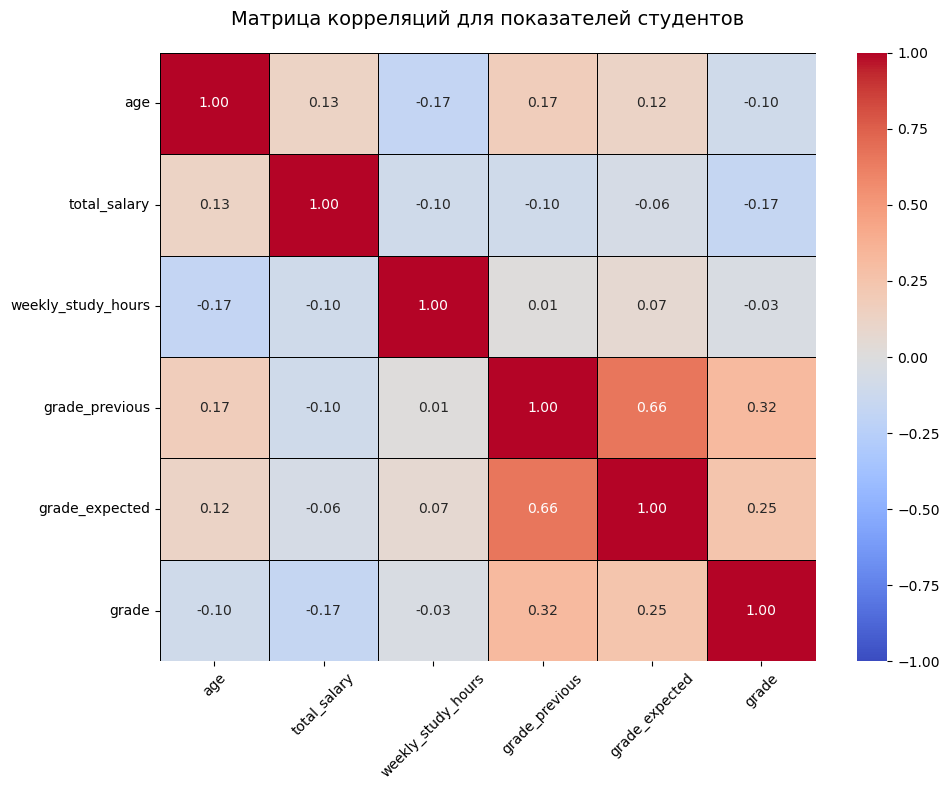

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

# Выбираем только числовые столбцы для корреляции
numeric_cols = ['age', 'total_salary', 'weekly_study_hours', 
               'grade_previous', 'grade_expected', 'grade']

# Создаем матрицу корреляций
corr_matrix = normalized_data[numeric_cols].corr()

# Настраиваем размер графика
plt.figure(figsize=(10, 8))

# Строим тепловую карту с аннотациями
sns.heatmap(corr_matrix, 
           annot=True, 
           cmap='coolwarm', 
           vmin=-1, 
           vmax=1,
           linewidths=0.5,
           linecolor='black',
           fmt=".2f")

# Добавляем заголовок
plt.title('Матрица корреляций для показателей студентов', pad=20, fontsize=14)

# Поворачиваем подписи для лучшей читаемости
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Показываем график
plt.tight_layout()
plt.show()

In [142]:
import pandas as pd

def get_dataset_statistics(data):
    """
    Генерирует основные статистики для набора данных.
    
    Параметры:
    - data: DataFrame с данными.
    
    Возвращает:
    - Словарь с различными статистиками.
    """
    
    stats = {}
    
    # 1. Общая информация о данных
    stats['shape'] = data.shape
    stats['columns'] = list(data.columns)
    stats['dtypes'] = data.dtypes.to_dict()
    
    # 2. Пропущенные значения
    stats['missing_values'] = data.isnull().sum().to_dict()
    
    # 3. Основные статистики для числовых столбцов
    numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
    stats['describe'] = data[numeric_cols].describe().to_dict()
    
    # 4. Уникальные значения для категориальных столбцов
    categorical_cols = data.select_dtypes(include=['object', 'category']).columns
    stats['unique_values'] = {col: data[col].unique().tolist() for col in categorical_cols}
    
    # 5. Корреляционная матрица для числовых столбцов
    stats['correlation_matrix'] = data[numeric_cols].corr().to_dict()
    
    # 6. Частоты для категориальных переменных
    stats['value_counts'] = {col: data[col].value_counts().to_dict() for col in categorical_cols}
    
    return stats

In [178]:

dataset_stats = get_dataset_statistics(normalized_data)

# Пример доступа к статистикам:
print("Размер данных:", dataset_stats['shape'])
print("Пропущенные значения:", dataset_stats['missing_values'])
print("Основные статистики для числовых столбцов:", dataset_stats['describe'])




Размер данных: (145, 32)
Пропущенные значения: {'age': 0, 'sex': 0, 'graduated_h_school_type': 0, 'scholarship_type': 0, 'additional_work': 0, 'activity': 0, 'partner': 0, 'total_salary': 0, 'transport': 0, 'accomodation': 0, 'mother_ed': 0, 'farther_ed': 0, 'siblings': 0, 'parental_status': 0, 'mother_occup': 0, 'father_occup': 0, 'weekly_study_hours': 0, 'reading_non_scientific': 0, 'reading_scientific': 0, 'attendance_seminars_dep': 0, 'impact_of_projects': 0, 'attendances_classes': 0, 'preparation_midterm_company': 0, 'preparation_midterm_time': 0, 'taking_notes': 0, 'listenning': 0, 'discussion_improves_interest': 0, 'flip_classrom': 0, 'grade_previous': 0, 'grade_expected': 0, 'course_id': 0, 'grade': 0}
Основные статистики для числовых столбцов: {'age': {'count': 145.0, 'mean': 1.7151031552830004e-16, 'std': 1.000000000000001, 'min': -1.012289951855988, '25%': -1.012289951855988, '50%': 0.6186216372453263, '75%': 0.6186216372453263, 'max': 2.2495332263466405}, 'sex': {'count': 1

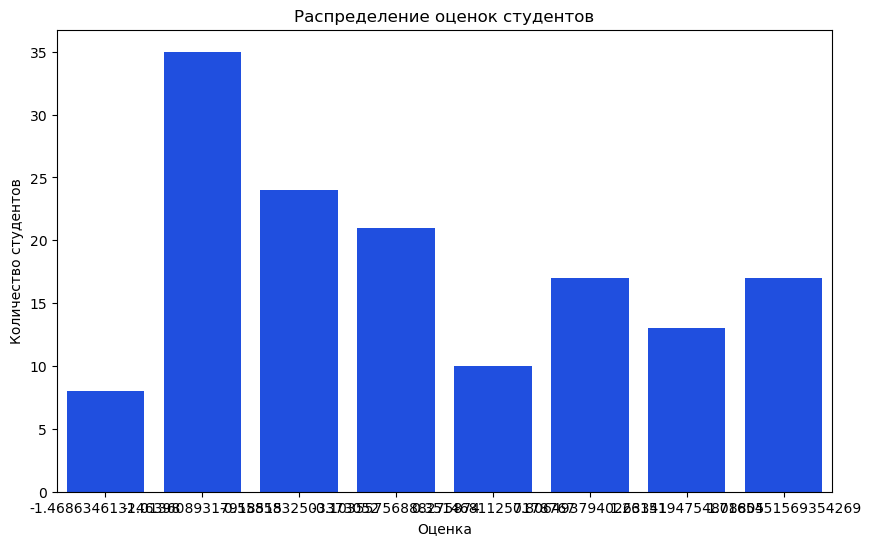

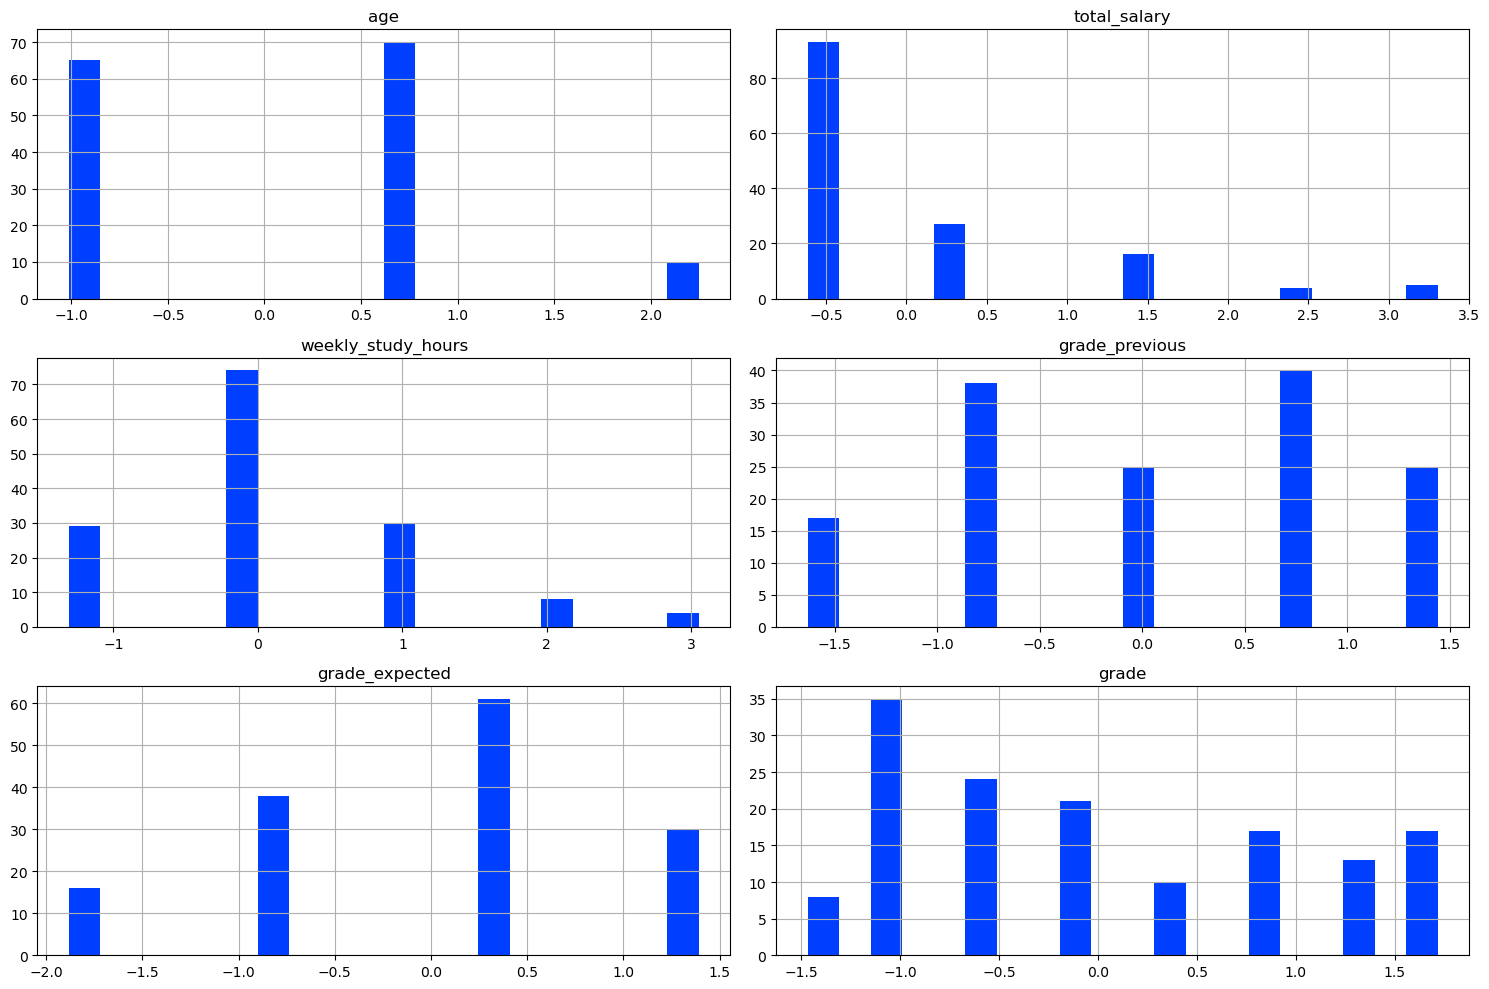

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='grade', data=normalized_data)
plt.title('Распределение оценок студентов')
plt.xlabel('Оценка')
plt.ylabel('Количество студентов')
plt.show()
numeric_cols = ['age', 'total_salary', 'weekly_study_hours', 'grade_previous', 'grade_expected', 'grade']

# Гистограммы распределений
normalized_data[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()







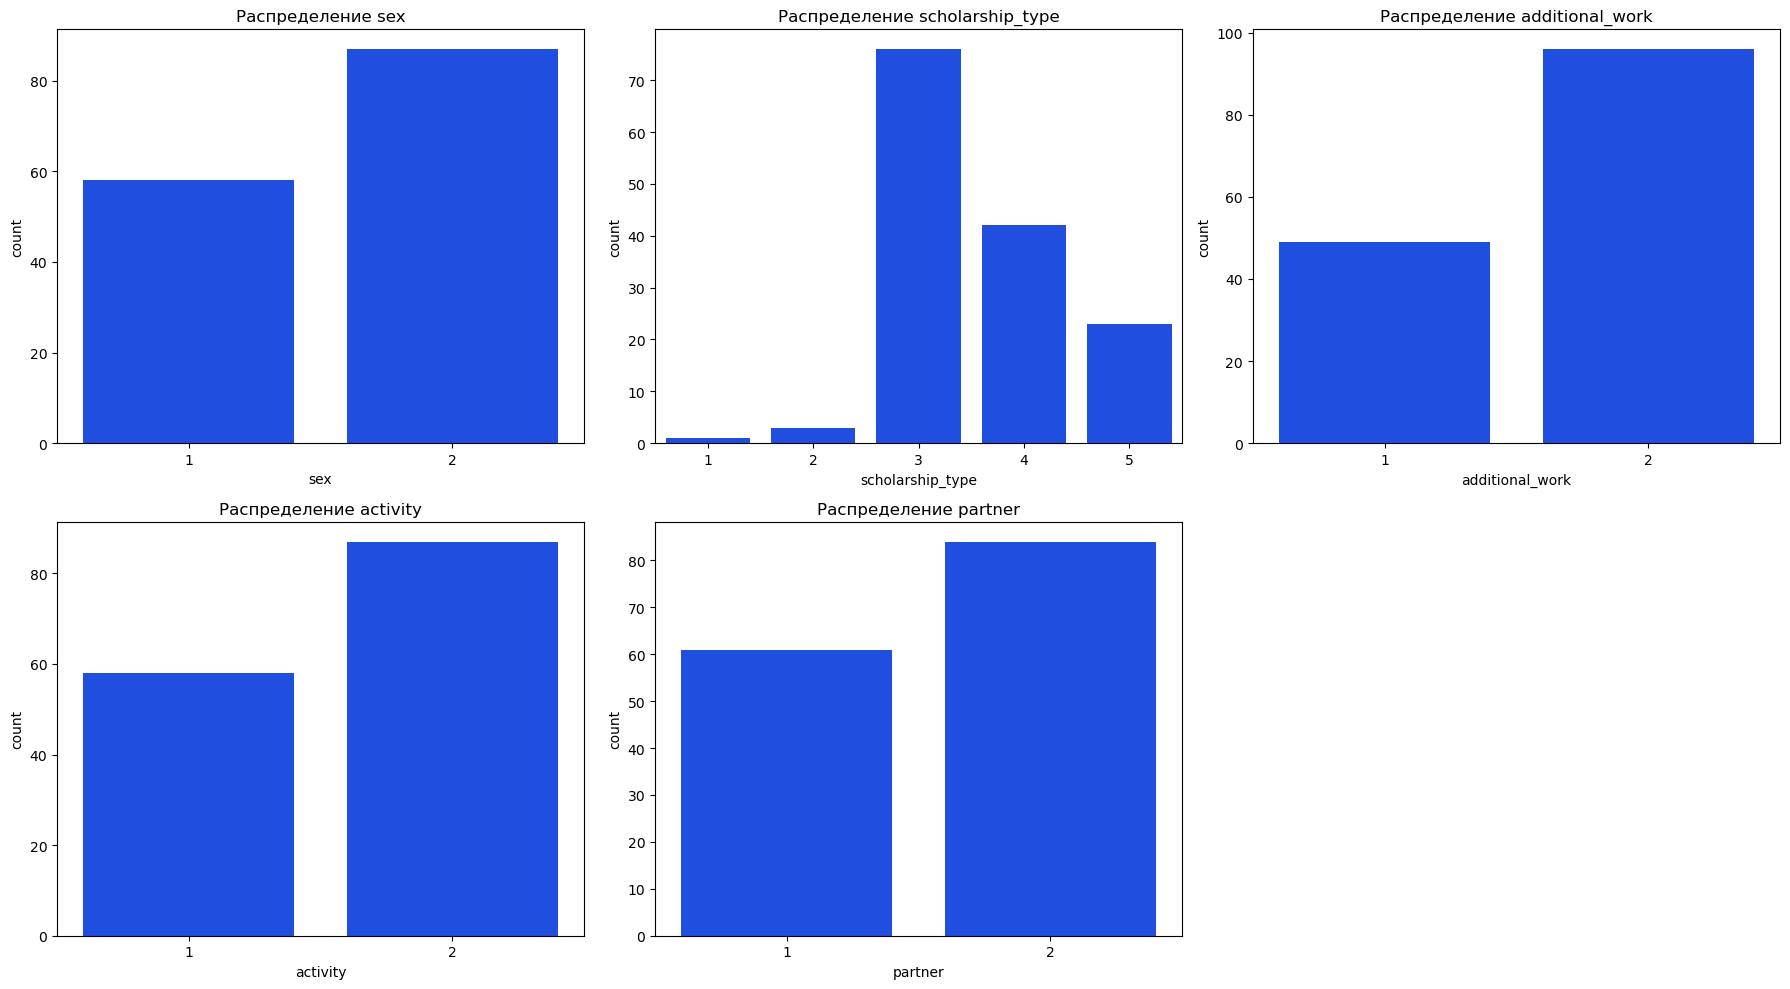

In [182]:
categorical_cols = ['sex', 'scholarship_type', 'additional_work', 'activity', 'partner']

# Столбчатые диаграммы для категориальных признаков


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=normalized_data, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
# Скрываем лишнюю ось
axes[-1].axis('off')



plt.tight_layout()
plt.show()

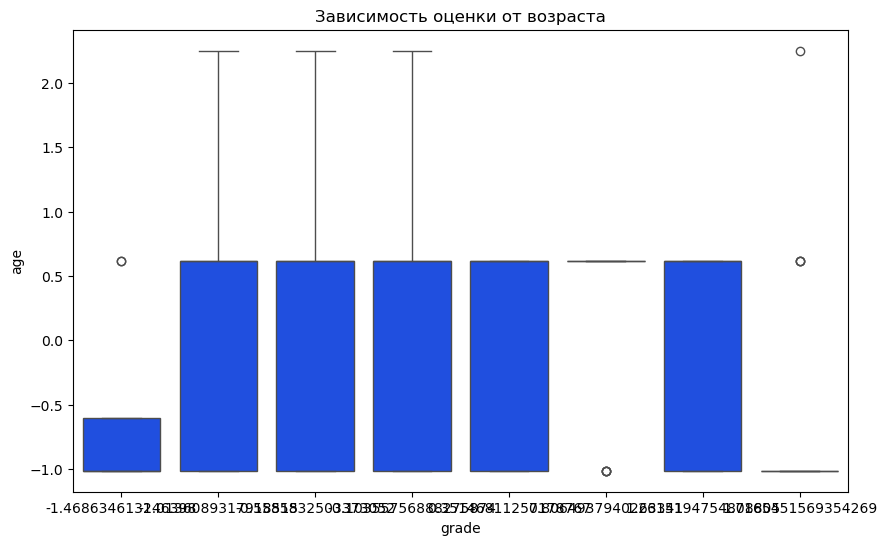

In [184]:
# Зависимость оценки от возраста
plt.figure(figsize=(10, 6))
sns.boxplot(x='grade', y='age', data=normalized_data)
plt.title('Зависимость оценки от возраста')
plt.show()

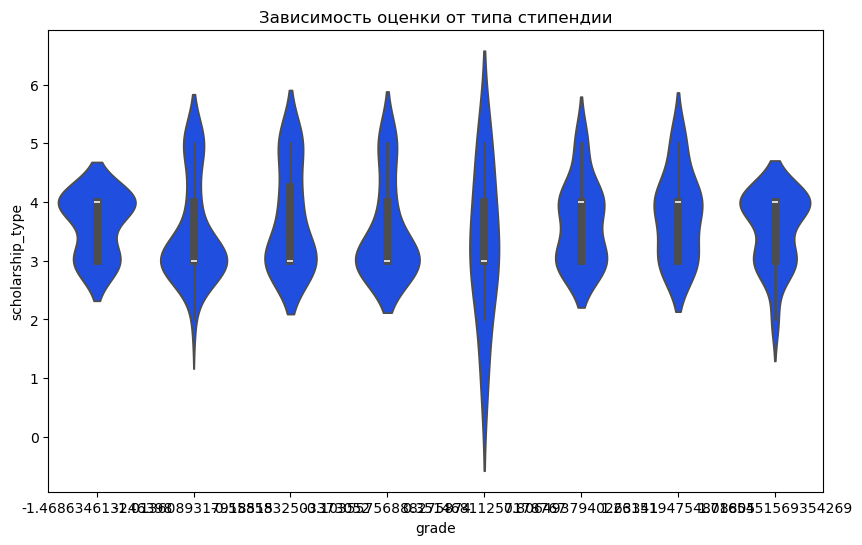

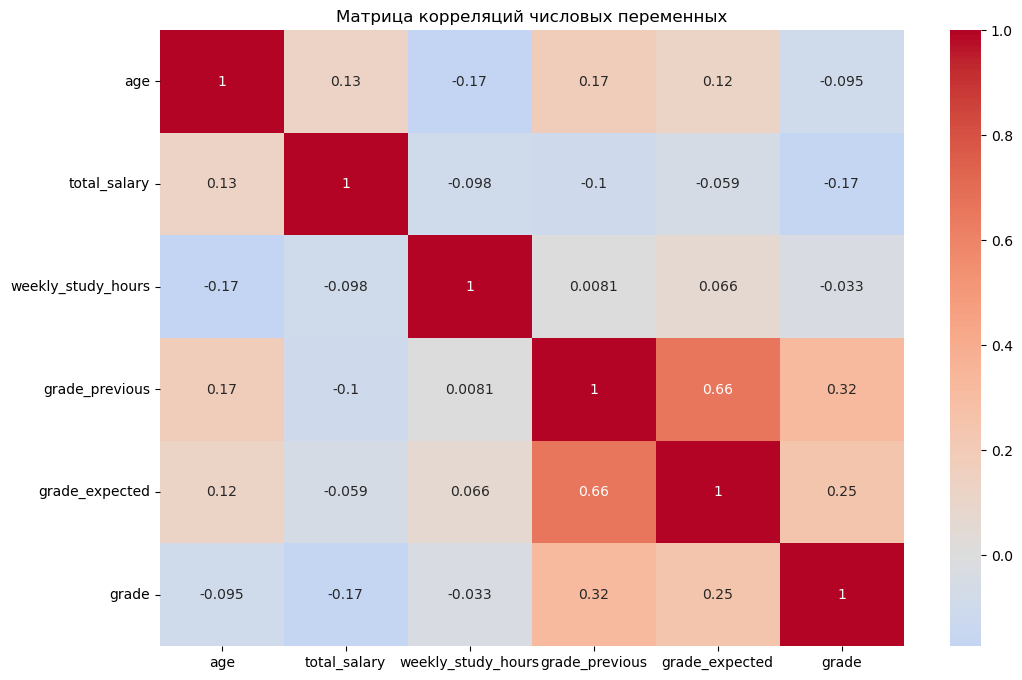

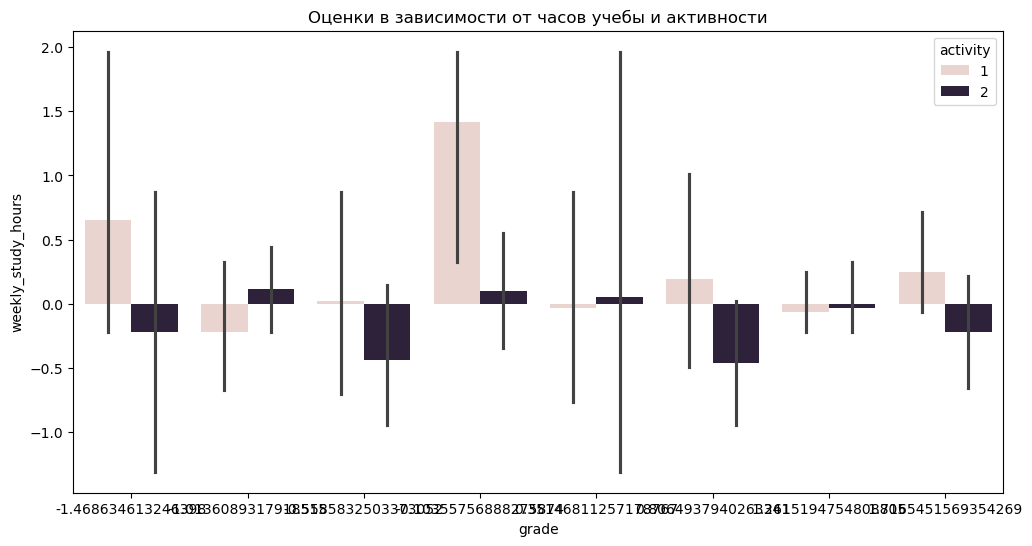

In [186]:

# Зависимость оценки от типа стипендии
plt.figure(figsize=(10, 6))
sns.violinplot(x='grade', y='scholarship_type', data=normalized_data)
plt.title('Зависимость оценки от типа стипендии')
plt.show()
plt.figure(figsize=(12, 8))
sns.heatmap(normalized_data[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций числовых переменных')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='grade', y='weekly_study_hours', hue='activity', data=normalized_data)
plt.title('Оценки в зависимости от часов учебы и активности')
plt.show()

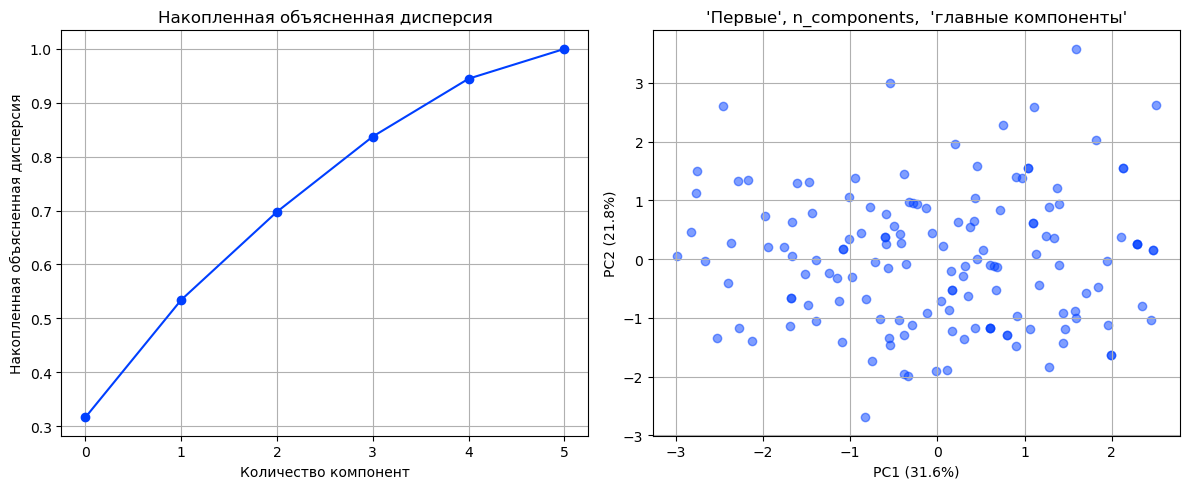


Информация о PCA модели:
Объясненная дисперсия (каждая компонента): [0.316 0.218 0.164 0.14  0.107 0.055]
Суммарная объясненная дисперсия: 1.0
Форма преобразованных данных: (145, 6)


In [200]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def apply_pca(data, n_components=None):
    """
    Применяет PCA к данным и визуализирует результаты.
    
    Параметры:
    ----------
    data : pandas.DataFrame
        Нормализованные данные (после центрирования и нормирования)
    n_components : int или None
        Количество главных компонент (если None - оставляет все)
    
    Возвращает:
    -----------
    pca_result : numpy.ndarray
        Преобразованные данные в пространстве главных компонент
    pca_model : sklearn.decomposition.PCA
        Обученная модель PCA для дальнейшего анализа
    """
    
    # 1. Инициализация PCA
    # ---------------------
    # Создаем объект PCA. Если n_components=None, будут сохранены все компоненты
    pca = PCA(n_components=n_components)
    
    # 2. Применение PCA к данным
    # --------------------------
    # fit_transform - обучает модель и сразу преобразует данные
    pca_result = pca.fit_transform(data)
    
    # 3. Визуализация результатов
    # ---------------------------
    plt.figure(figsize=(12, 5))
    
    # График объясненной дисперсии
    plt.subplot(1, 2, 1)
    plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-')
    plt.xlabel('Количество компонент')
    plt.ylabel('Накопленная объясненная дисперсия')
    plt.title('Накопленная объясненная дисперсия')
    plt.grid(True)
    
    # Scatter plot первых двух компонент (если есть хотя бы 2 компоненты)
    if pca_result.shape[1] >= 2:
        plt.subplot(1, 2, 2)
        plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
        plt.xlabel('PC1 ({}%)'.format(round(pca.explained_variance_ratio_[0]*100, 1)))
        plt.ylabel('PC2 ({}%)'.format(round(pca.explained_variance_ratio_[1]*100, 1)))
        plt.title("'Первые две главные компоненты)
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Вывод информации о модели
    # ----------------------------
    print("\nИнформация о PCA модели:")
    print("Объясненная дисперсия (каждая компонента):", np.round(pca.explained_variance_ratio_, 3))
    print("Суммарная объясненная дисперсия:", round(np.sum(pca.explained_variance_ratio_), 3))
    print("Форма преобразованных данных:", pca_result.shape)
    
    return pca_result, pca

# Пример использования:
# Предположим, normalized_data - это ваши нормализованные данные
# Выбираем только числовые столбцы (исключаем ID, категориальные)
numeric_cols = ['age', 'total_salary', 'weekly_study_hours', 
                'grade_previous', 'grade_expected', 'grade']
pca_data, pca_model = apply_pca(normalized_data[numeric_cols], n_components=6)

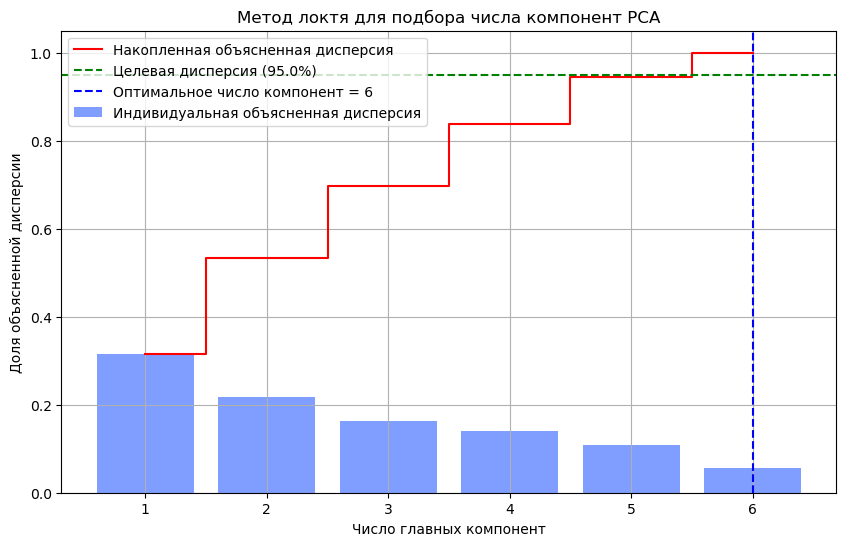

Оптимальное число компонент, сохраняющее 95.0% дисперсии: 6
Объясненная дисперсия для 6 компонент: 1.000


In [194]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def find_optimal_components(data, variance_threshold=0.95):
    """
    Находит оптимальное число главных компонент, сохраняющих заданную долю дисперсии.
    
    Параметры:
    ----------
    data : pandas.DataFrame или numpy.ndarray
        Нормализованные данные для анализа
    variance_threshold : float (от 0 до 1)
        Желаемая доля сохраняемой дисперсии (по умолчанию 95%)
    
    Возвращает:
    -----------
    optimal_num : int
        Оптимальное количество компонент
    """
    
    # 1. Инициализация PCA со всеми возможными компонентами
    pca = PCA().fit(data)
    
    # 2. Вычисление накопленной объясненной дисперсии
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    
    # 3. Нахождение точки, где достигается порог дисперсии
    optimal_num = np.where(cumulative_variance >= variance_threshold)[0][0] + 1
    
    # 4. Визуализация "Локтевого метода"
    plt.figure(figsize=(10, 6))
    
    # График объясненной дисперсии для каждой компоненты
    plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_,
            alpha=0.5,
            align='center',
            label='Индивидуальная объясненная дисперсия')
    
    # График накопленной объясненной дисперсии
    plt.step(range(1, len(cumulative_variance) + 1),
             cumulative_variance,
             where='mid',
             label='Накопленная объясненная дисперсия',
             color='red')
    
    # Линия порогового значения
    plt.axhline(y=variance_threshold, color='green', linestyle='--', 
                label=f'Целевая дисперсия ({variance_threshold*100}%)')
    
    # Вертикальная линия оптимального числа компонент
    plt.axvline(x=optimal_num, color='blue', linestyle='--', 
                label=f'Оптимальное число компонент = {optimal_num}')
    
    # Настройки графика
    plt.ylabel('Доля объясненной дисперсии')
    plt.xlabel('Число главных компонент')
    plt.title('Метод локтя для подбора числа компонент PCA')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()
    
    # 5. Вывод информации
    print(f"Оптимальное число компонент, сохраняющее {variance_threshold*100}% дисперсии: {optimal_num}")
    print(f"Объясненная дисперсия для {optimal_num} компонент: {cumulative_variance[optimal_num-1]:.3f}")
    
    return optimal_num

# Пример использования:
# Предположим, normalized_data - это ваши нормализованные данные
numeric_cols = ['age', 'total_salary', 'weekly_study_hours', 
                'grade_previous', 'grade_expected', 'grade']
optimal_n = find_optimal_components(normalized_data[numeric_cols])

# Теперь можно применить PCA с оптимальным числом компонент
pca = PCA(n_components=optimal_n)
pca_result = pca.fit_transform(normalized_data[numeric_cols])

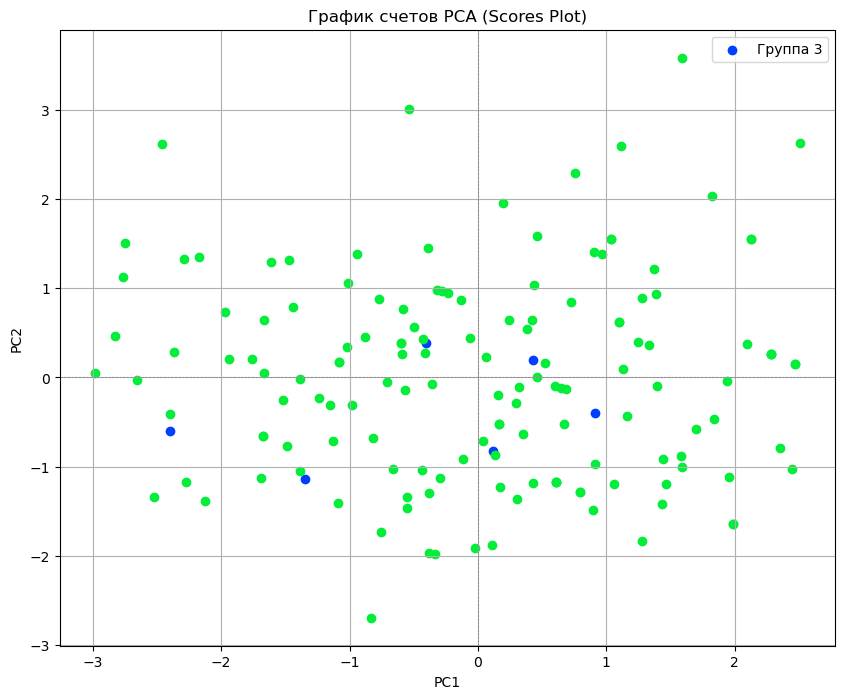

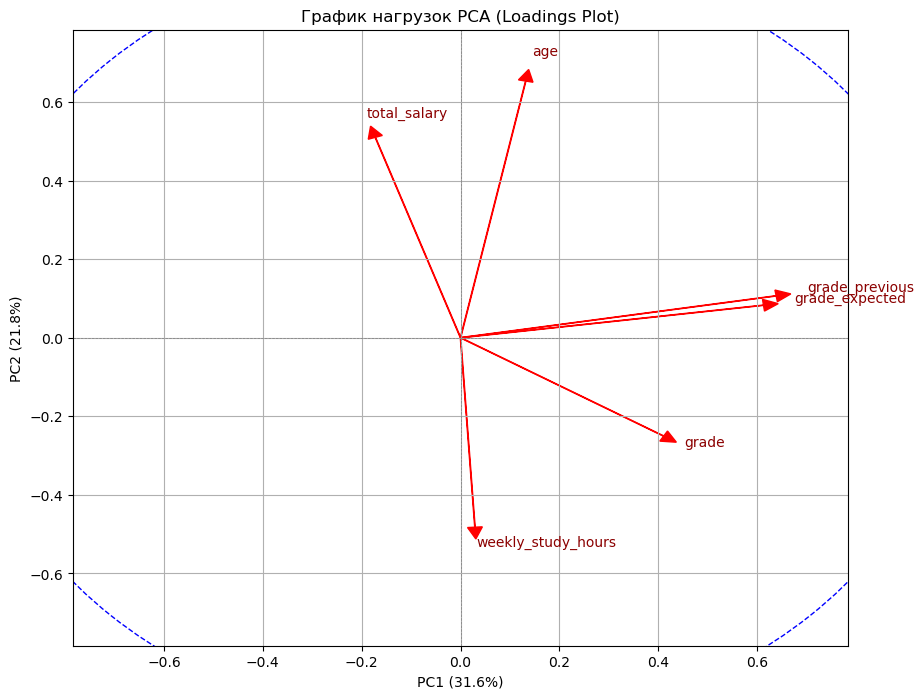

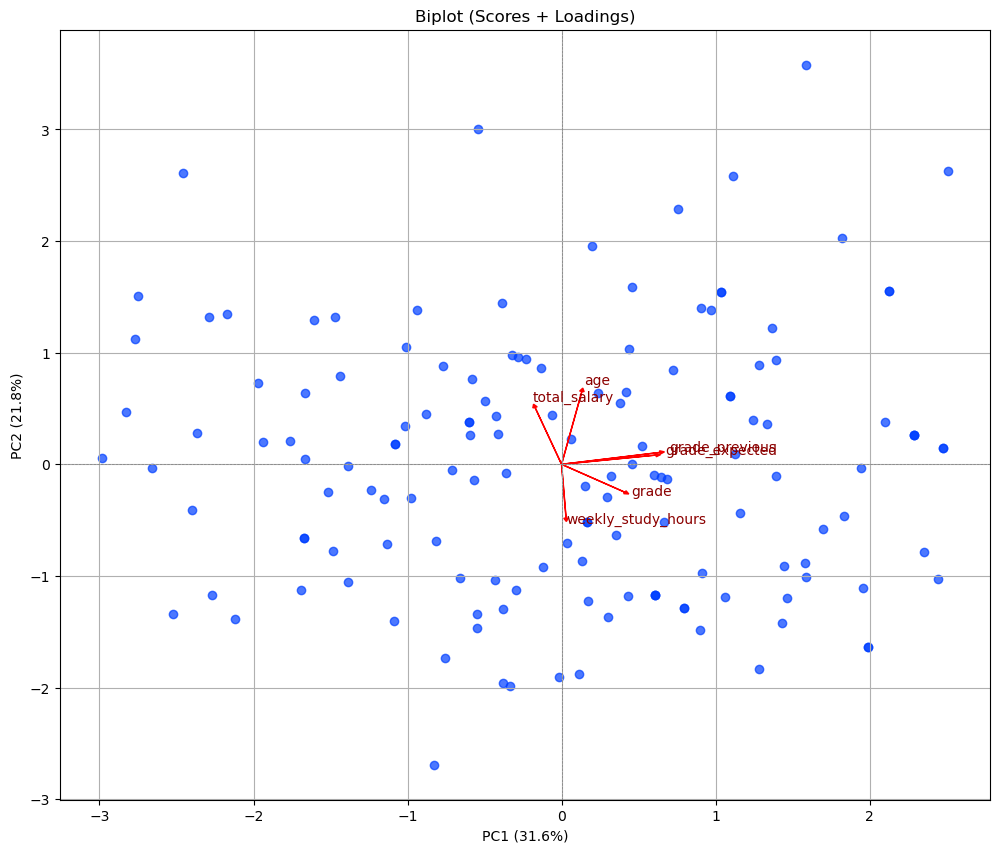

In [218]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_pca_scores(pca_scores, labels=None, alpha=0.7, ellipse=False):
    """
    Визуализирует PCA scores (проекции объектов на главные компоненты).
    
    Параметры:
    ----------
    pca_scores : numpy.ndarray
        Массив с результатами PCA (полученный из pca.transform())
    labels : array-like, optional
        Метки классов/групп для цветового разделения точек
    alpha : float, optional
        Прозрачность точек (по умолчанию 0.7)
    ellipse : bool, optional
        Если True, рисует эллипсы для групп (по умолчанию False)
    """
    plt.figure(figsize=(10, 8))
    
    # Если есть метки, используем их для раскраски точек
    if labels is not None:
        unique_labels = np.unique(labels)
        for label in unique_labels:
            mask = labels == label
            plt.scatter(pca_scores[mask, 0], pca_scores[mask, 1], 
                        label=f'Группа {label}', alpha=alpha)
            
            # Добавляем эллипсы для групп
    if ellipse:
                cov = np.cov(pca_scores[mask, :2].T)
                lambda_, v = np.linalg.eig(cov)
                angle = np.degrees(np.arctan2(v[0, 1], v[0, 0]))
                ell = Ellipse(xy=np.mean(pca_scores[mask, :2], axis=0),  # добавлено axis=0
                              width=np.sqrt(lambda_[0])*2, 
                              height=np.sqrt(lambda_[1])*2,
                              angle=angle, fill=False, 
                              linestyle='--', linewidth=1)  # добавлена закрывающая скобка
                plt.gca().add_patch(ell)

    else:
        plt.scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=alpha)
    
    # Настройка осей и легенды
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('График счетов PCA (Scores Plot)')
    plt.grid(True)
    
    if labels is not None:
        plt.legend()
    plt.show()

def plot_pca_loadings(pca_model, feature_names, arrow_scale=1.0):
    """
    Визуализирует PCA loadings (вклад исходных признаков в компоненты).
    
    Параметры:
    ----------
    pca_model : sklearn.decomposition.PCA
        Обученная модель PCA
    feature_names : list
        Список имен признаков
    arrow_scale : float, optional
        Масштаб стрелок (по умолчанию 1.0)
    """
    plt.figure(figsize=(10, 8))
    
    # Получаем нагрузки для первых двух компонент
    loadings = pca_model.components_[:2].T
    
    # Рисуем стрелки (вектора нагрузок)
    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, 
                  loadings[i, 0]*arrow_scale, 
                  loadings[i, 1]*arrow_scale,
                  head_width=0.03, head_length=0.03, 
                  fc='red', ec='red')
        plt.text(loadings[i, 0]*arrow_scale*1.1, 
                 loadings[i, 1]*arrow_scale*1.1,
                 feature, color='darkred')
    
    # Настройка осей и границ
    max_val = np.max(np.abs(loadings)) * 1.2
    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)
    
    # Добавляем окружность (для корреляционного анализа)
    circle = plt.Circle((0, 0), 1, fill=False, color='blue', linestyle='--')
    plt.gca().add_patch(circle)
    
    # Настройка графика
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.xlabel('PC1 ({}%)'.format(round(pca_model.explained_variance_ratio_[0]*100, 1)))
    plt.ylabel('PC2 ({}%)'.format(round(pca_model.explained_variance_ratio_[1]*100, 1)))
    plt.title('График нагрузок PCA (Loadings Plot)')
    plt.grid(True)
    plt.show()

def plot_biplot(pca_scores, pca_model, feature_names, labels=None, alpha=0.7, arrow_scale=1.0):
    """
    Совмещает график счетов и нагрузок (biplot).
    
    Параметры:
    ----------
    pca_scores : numpy.ndarray
        Массив с результатами PCA
    pca_model : sklearn.decomposition.PCA
        Обученная модель PCA
    feature_names : list
        Список имен признаков
    labels : array-like, optional
        Метки классов/групп
    alpha : float, optional
        Прозрачность точек
    arrow_scale : float, optional
        Масштаб стрелок
    """
    plt.figure(figsize=(12, 10))
    
    # 1. Рисуем scores (точки данных)
    if labels is not None:
        unique_labels = np.unique(labels)
        for label in unique_labels:
            mask = labels == label
            plt.scatter(pca_scores[mask, 0], pca_scores[mask, 1], 
                        label=f'Группа {label}', alpha=alpha)
    else:
        plt.scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=alpha)
    
    # 2. Рисуем loadings (стрелки)
    loadings = pca_model.components_[:2].T
    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, 
                  loadings[i, 0]*arrow_scale, 
                  loadings[i, 1]*arrow_scale,
                  head_width=0.03, head_length=0.03, 
                  fc='red', ec='red')
        plt.text(loadings[i, 0]*arrow_scale*1.1, 
                 loadings[i, 1]*arrow_scale*1.1,
                 feature, color='darkred')
    
    # 3. Настройка графика
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.xlabel('PC1 ({}%)'.format(round(pca_model.explained_variance_ratio_[0]*100, 1)))
    plt.ylabel('PC2 ({}%)'.format(round(pca_model.explained_variance_ratio_[1]*100, 1)))
    plt.title('Biplot (Scores + Loadings)')
    plt.grid(True)
    
    if labels is not None:
        plt.legend()
    plt.show()

# Пример использования:
# Предположим, у нас уже есть:
# - pca_result - результаты PCA (scores)
# - pca_model - обученная модель PCA
# - numeric_cols - список числовых признаков

# 1. График счетов
plot_pca_scores(pca_result, 3, True)

# 2. График нагрузок
plot_pca_loadings(pca_model, numeric_cols)

# 3. Biplot (объединенный график)
plot_biplot(pca_result, pca_model, numeric_cols)